In [1]:
!pip install torch torchvision opencv-python matplotlib

In [3]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [4]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Saving four-adorable-pets.webp to four-adorable-pets.webp


In [5]:
import torchvision.transforms as T

transform = T.Compose([T.ToTensor()])
input_tensor = transform(img_rgb).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)[0]

masks = output['masks']
labels = output['labels']
scores = output['scores']

In [6]:
segmented = img_rgb.copy()

for i in range(len(masks)):
    if scores[i] > 0.7:
        mask = masks[i][0].numpy()
        color = np.random.randint(0,255,(3,))
        segmented[mask > 0.5] = (
            0.6 * segmented[mask > 0.5] + 0.4 * color
        )

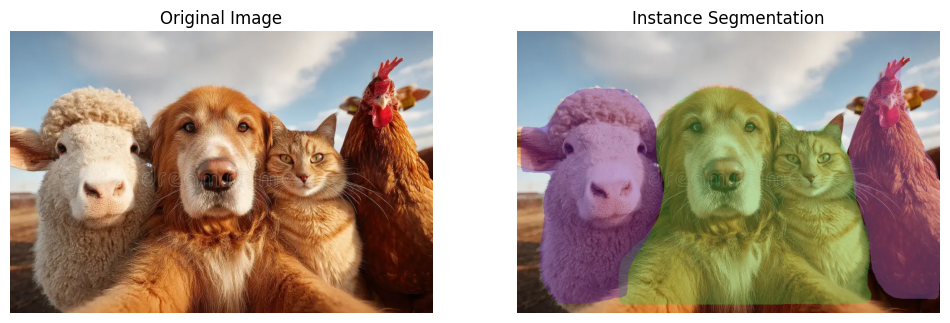

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Instance Segmentation")
plt.imshow(segmented)
plt.axis('off')

plt.show()